## Simulador - Bubble

Notebook para simulação inicial do projeto Bubble.

- Temos uma grafo $G$ com $num\_nodes$ vértices, onde cada vértice possui $|words\_per\_node|$ palavras de interesse.

In [192]:
import networkx as nx
import numpy as np
import copy
import matplotlib.pyplot as plt

In [193]:
class BubbleModel:
    def __init__(self, hp:dict):
        self.stage = 0
        self.num_nodes = hp['num_nodes']
        self.words_per_node = hp['words_per_node']
        self.affinity_level = hp['affinity_level']
        self.edge_count = np.ndarray(0)
        self.initial_edge_count = np.zeros(4,dtype=int)

        # Graph initialization
        if len(hp['labels']) == self.num_nodes:
            self.labels = (np.array(hp['labels']) != hp['labels'][0]).astype(bool)
        else:
            self.labels = np.random.randint(0,2,self.num_nodes).astype(bool)

        if hp['alphaR'] is None or len(hp['alphaR']) != sum(self.words_per_node):
            self.alphaR = np.ones(self.words_per_node[1])
        else:
            self.alphaR = np.maximum(hp['alphaR'],np.zeros(self.num_nodes))

        if hp['alphaL'] is None or len(hp['alphaL']) != sum(self.words_per_node):
            self.alphaL = np.ones(self.words_per_node[0])
        else:
            self.alphaL = np.maximum(hp['alphaL'],np.zeros(self.num_nodes))

        self.p = np.zeros((self.num_nodes, sum(self.words_per_node)))
        for i in range(self.num_nodes):
            if self.labels[i] == 0:
                self.p[i] = np.concatenate([np.random.dirichlet(self.alphaL),np.zeros(self.words_per_node[1])])
            else:
                self.p[i] = np.concatenate([np.zeros(self.words_per_node[0]),np.random.dirichlet(self.alphaR)])

        self.G = nx.Graph()
        self.G.add_nodes_from([(i, {'p': self.p[i], 'label': self.labels[i]}) for i in range(self.num_nodes)])

        # Parameters processing
        if np.isscalar(hp['beta']):
            self.beta = np.full(self.num_nodes, hp['beta'])
        else:
            self.beta = hp['beta']

        if np.isscalar(hp['gamma']):
            self.gamma = np.full(self.num_nodes, hp['gamma'])
        else:
            self.gamma = hp['gamma']

        # Functions processing
        self.affinity = hp['affinity']
        self.influencer_selection = hp['influencer_selection']

        # Network initialization
        for i in range(self.num_nodes):
            for j in range(i + 1, self.num_nodes):
                self.update_edge(i, j)
        self.edge_count = np.zeros((1,4),dtype=int)
        self.edge_count[0] = self.initial_edge_count

    def update_edge(self, node1, node2):
        v1 = self.G.nodes[node1]['p']
        v2 = self.G.nodes[node2]['p']

        if self.affinity(v1,v2) >= self.affinity_level and not self.G.has_edge(node1, node2):
            self.G.add_edge(node1, node2)
            if self.stage == 0:
                self.initial_edge_count[self.labels[node1]+2*self.labels[node2]] += 1
            else:
                self.edge_count[self.stage][self.labels[node1]+2*self.labels[node2]] += 1
        elif self.affinity(v1,v2) < self.affinity_level and self.G.has_edge(node1, node2):
            self.G.remove_edge(node1, node2)
            if self.stage == 0:
                self.initial_edge_count[self.labels[node1]+2*self.labels[node2]] -= 1
            else:
                self.edge_count[self.stage][self.labels[node1]+2*self.labels[node2]] -= 1
    def iteration(self, msg0, msg1):
        # Step 1
        self.influencer_nodes = self.influencer_selection(self.G)

        for ind in range(len(self.influencer_nodes)):
            i = self.influencer_nodes[ind]
            if self.G.nodes[i]['label'] == 0:
                self.G.nodes[i]['p'] = ((1 - self.beta[i]) * self.G.nodes[i]['p'] + self.beta[i] * msg0)
            else:
                self.G.nodes[i]['p'] = ((1 - self.beta[i]) * self.G.nodes[i]['p'] + self.beta[i] * msg1)

        # Step 2
        for i in range(self.num_nodes):
            if i not in self.influencer_nodes:
                Nu = []
                for j in self.influencer_nodes:
                    if self.G.has_edge(i, j):
                        Nu.append(j)

                if len(Nu) > 0:
                    profile_sum = np.zeros(np.sum(self.words_per_node))
                    for k in Nu:
                        profile_sum += self.G.nodes[k]['p'] / len(Nu)
                else:
                    profile_sum = self.G.nodes[i]['p']

                self.G.nodes[i]['p'] = ((1 - self.gamma[i]) * self.G.nodes[i]['p'] + self.gamma[i] * profile_sum)
                
        # Step 3
        for i in range(self.num_nodes):
            for j in range(i + 1, self.num_nodes):
                self.update_edge(i, j)

    def run(self, n, msg0, msg1):
        self.edge_count = np.zeros((n+1,4),dtype=int)
        self.edge_count[0] = self.initial_edge_count
        for i in range(n):
            self.stage = i+1
            self.iteration(msg0,msg1)
            self.edge_count[i+1] += self.edge_count[i]
        return self.G
    
    def plot_edge_counts(self):
        steps = range(len(self.edge_count))
        plt.figure(figsize=(10, 5))
        plt.plot(steps, self.edge_count[:, 0], label=r'$L_0 \leftrightarrow L_0$', color='royalblue')
        plt.plot(steps, self.edge_count[:, 3], label=r'$L_1 \leftrightarrow L_1$', color='crimson')
        plt.plot(steps, self.edge_count[:, 1] + self.edge_count[:, 2], label=r'$L_0 \leftrightarrow L_1$', color='indigo', linestyle='--')
        plt.title('Arestas x Iteração')
        plt.xlabel('Iteração')
        plt.ylabel('Total de Arestas')
        plt.legend()
        plt.show()

### Funções de Afinidade

In [194]:
def affinity_cos(u, v):
    return np.dot(u,v)/(np.linalg.norm(u)*np.linalg.norm(v))

### Funções de Seleção de Influencers

In [195]:
def selection_max_degree(G):
    max_degrees = [(-1, -1), (-1, -1)]

    for node_id, attrs in G.nodes(data=True):
        degree = G.degree(node_id)
        label = attrs.get('label')
        
        if label == 0 and degree > max_degrees[0][0]:
            max_degrees[0] = (degree, node_id)
        elif label == 1 and degree > max_degrees[1][0]:
            max_degrees[1] = (degree, node_id)

    return [max_degrees[0][1], max_degrees[1][1]]

### Função de Detecção de Bubble Burst

In [196]:
def cross_group_connectivity(G, words_per_node): 
    total_cross_group_edges_possible = words_per_node[0] * words_per_node[1]
    cross_group_edges = 0

    for node1 in range(len(G.nodes)):
        for node2 in range(node1 + 1, len(G.nodes)):
            l1 = G.nodes[node1]['label']
            l2 = G.nodes[node2]['label']

            if l1 != l2 and G.has_edge(node1, node2):
                cross_group_edges += 1
    return cross_group_edges / total_cross_group_edges_possible

### Tipos de Mensagem

In [197]:
def msg_unif(k,label):
    msg = np.zeros(np.sum(k))
    if label == 1:
        msg[:k[0]] = np.ones(k[label]) / k[label]
    else:
        msg[k[0]:] = np.ones(k[label]) / k[label]
    return msg

### Simulação

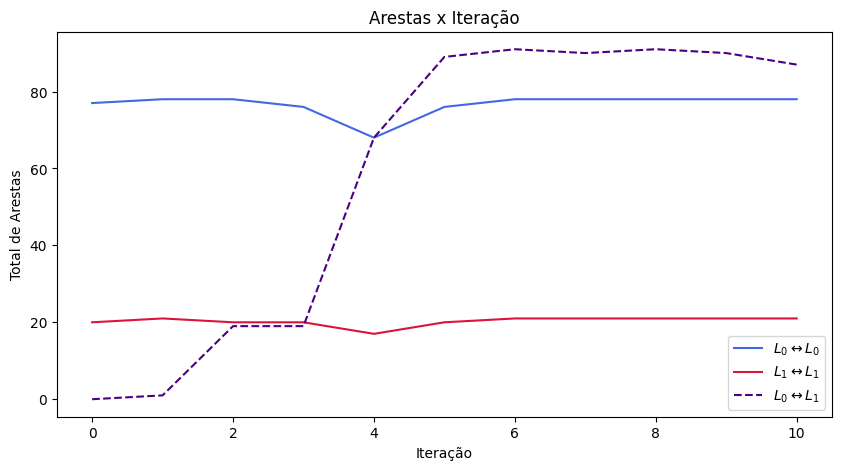

In [198]:
defaultModel = {
    'num_nodes': 20,
    'words_per_node': (4,4),
    'affinity_level': 0.1,
    'labels': [],
    'alphaL': None,
    'alphaR': None,
    'beta': 0.3,
    'gamma': 0.2,
    'affinity': np.dot,
    'influencer_selection': selection_max_degree,
    'bubble_burst': cross_group_connectivity,
}

def create_model(changes):
    model = copy.deepcopy(defaultModel)
    model.update(changes)
    return model

g = BubbleModel(defaultModel)
res = g.run(10,msg_unif(g.words_per_node,0),msg_unif(g.words_per_node,1))
g.plot_edge_counts()